# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
df = pd.read_csv('online_retail_clustering.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2.465366,2
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2.904194,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [3]:
df[['Quantity', 'UnitPrice']] = np.log1p(df[['Quantity', 'UnitPrice']])

df['Country'] = df.groupby('Country')['TotalAmount'].transform('mean')
df['Frequency'] = df.groupby('CustomerID')['InvoiceNo'].transform('count')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Cluster,Frequency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1.945910,2010-12-01 08:26:00,1.266948,17850.0,1.750195,2.465366,2,289
1,536365,71053,WHITE METAL LANTERN,1.945910,2010-12-01 08:26:00,1.479329,17850.0,1.750195,2.878642,2,289
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,2.197225,2010-12-01 08:26:00,1.321756,17850.0,1.750195,2.904194,2,289
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,1.945910,2010-12-01 08:26:00,1.479329,17850.0,1.750195,2.878642,2,289
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,1.945910,2010-12-01 08:26:00,1.479329,17850.0,1.750195,2.878642,2,289


In [4]:
df.drop(['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'InvoiceDate'], axis=1, inplace=True)

scaler = StandardScaler()
df[['Quantity', 'UnitPrice', 'TotalAmount', 'Frequency']] = scaler.fit_transform(df[['Quantity', 'UnitPrice', 'TotalAmount', 'Frequency']])

X = df.drop('Cluster', axis=1)
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(256828, 5)
(64207, 5)
(256828,)
(64207,)


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

In [5]:
model1 = XGBClassifier().fit(X_train, y_train)
model2 = KNeighborsClassifier().fit(X_train, y_train)
print('Model1 & Model2 sudah selesai di training')

Model1 & Model2 sudah selesai di training


Pada submission ini menggunakan 2 metode klasifikasi yaitu XGBClassifier dan KNeighborsClassifier. XGBClassifier merupakan salah satu bagian dari library XGBoost, XGBoost sendiri merupakan metode pembelajaran ensamble yang mengoptimalkan Gradient Boosting. XGBoost menggunakan pohon keputusan sebagai dasar pembelajarannya dan menggabungkannya secara berurutan untuk meningkatkan kinerja model. Setiap pohon baru dilatih untuk memperbaiki kesalahan yang dibuat oleh pohon sebelumnya dan proses ini disebut boosting.
XGBoost memiliki pemrosesan paralel bawaan untuk melatih model pada dataset yang besar dengan cepat. XGBoost juga mendukung kustomisasi yang memungkinkan pengguna untuk menyesuaikan parameter model untuk mengoptimalkan kinerja berdasarkan masalah tertentu. KNN algoritma yang mengklasifikasikan data berdasarkan kedekatannya dengan data lain yang sudah diberi label. Data baru diklasifikasikan ke dalam kelas yang paling umum di antara tetangga terdekatnya. KNN sangat sederhana, tetapi efektif, terutama ketika data memiliki pola yang jelas.

## **b. Evaluasi Model Klasifikasi**

In [6]:
def eval_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    return results

results = {
    'XGBClassifier': eval_model(model1, X_test, y_test),
    'KNeighborsClassifier': eval_model(model2, X_test, y_test)
}

summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Confusion Matrix'])

rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'Confusion Matrix': metrics['Confusion Matrix']
    })

summary_df = pd.DataFrame(rows)
print(summary_df)


                  Model  Accuracy  Precision    Recall  F1-Score  \
0         XGBClassifier  0.980687   0.980687  0.980687  0.980687   
1  KNeighborsClassifier  0.978305   0.978302  0.978305  0.978303   

                                   Confusion Matrix  
0  [[34877, 0, 618], [0, 3992, 0], [622, 0, 24098]]  
1  [[34810, 0, 685], [0, 3992, 0], [708, 0, 24012]]  


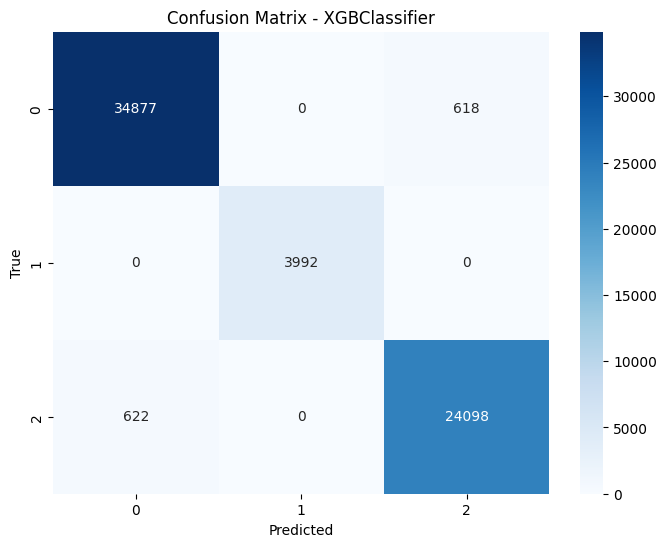

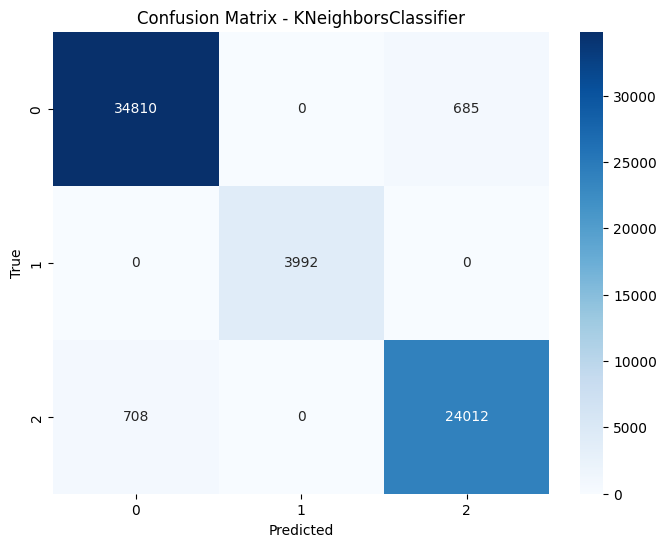

In [10]:
for index, row in summary_df.iterrows():
    cm = row['Confusion Matrix']
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {row["Model"]}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

Hasil dari kedua algoritma yang dipakai menunjukkan bahwa model dapat belajar dengan baik terhadap data latih ataupun data tes. Dapat dilihat dari nilai accuracy dan F!-SCore kedua algoritma yang cukup stabil pada 0.98 untuk XGBClassifier dan 0.97 untuk KNeighborsClassifier dan dibuktikan dengan confusion matrix di mana kedua algoritma dapat mengklafisikasikan cluster yang sesuai dengan cluster yang sebenarnya walaupun kedua algoritma masih ada kelemahan dengan salah melakukan klasifikasi cluster yang sesuai dengan cluster yang sebernya.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [ ]:
'''
xgb_param_dist = {
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'n_estimators': np.arange(50, 200, 10),
    'max_depth': np.arange(3, 10),
    'min_child_weight': np.arange(1, 10),
    'gamma': np.linspace(0, 0.5, 10),
    'subsample': np.linspace(0.5, 1, 10),
    'colsample_bytree': np.linspace(0.5, 1, 10),
}

random_search = RandomizedSearchCV(XGBClassifier(), xgb_param_dist, n_iter=50, cv=5, n_jobs=-1, verbose=1, random_state=42)
random_search.fit(X_train, y_train)

print("Best Hyperparameters:", random_search.best_params_)
print(random_search.score(X_train, y_train), random_search.best_score_, random_search.score(X_test, y_test))

best_xgb_model = random_search.best_estimator_
'''

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'subsample': 0.6666666666666666, 'n_estimators': 160, 'min_child_weight': 2, 'max_depth': 8, 'learning_rate': 0.07444444444444444, 'gamma': 0.0, 'colsample_bytree': 0.8888888888888888}
0.605257214945411 0.6007794978877827 0.6003551014686872


In [ ]:
'''
knn_param_dist = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

random_search = RandomizedSearchCV(KNeighborsClassifier(), knn_param_dist, n_iter=50, cv=5, n_jobs=-1, verbose=1, random_state=42)
random_search.fit(X_train, y_train)

print("Best Hyperparameters:", random_search.best_params_)
print(random_search.score(X_train, y_train), random_search.best_score_, random_search.score(X_test, y_test))]
'''

Fitting 5 folds for each of 50 candidates, totalling 250 fits


## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Pada submission ini tidak melakukan fine tunning tetapi melakukan feature engineering yaitu melakukan feature extraction pada kolom frequency dan melakukan penggurangan data yang tidak relevan seperti InvoiceNo, Description, Stockcode, InvoiDate dan CustomerID. Dengan melakukan feature engineering membuay kedua model atau kedua algortima yang digunakan dapat belajar dengan baik terhadap data latih dan data test yang dapat dilihat dengan nilai accuracy  dan f1-score sebesar 0.98 untuk XGBClassifier dan 0/97 untuk KNeighborsClassifier.
2. Kedua model yang digunakan baik XGBClassifier dan KNeighborsClassifier masih mempunyai kelemahan yaitu belum bisa sepenuhnya mengklasifikasi cluster yang sesuai dengan cluster yang sebenarnya. Dilihat pada plot confusion matrix kedua model sama-sama mengklasifikasikan cluster 0 sebagai cluster 2 dan sebaliknya. Ini terjadi kemungkinan karena besarnya frekuensi belanja dan uang yang dikeluarkan oleh pelanggan pada cluster 2 hampir mendekati besarnya frekuensi belanja dan uang yang dikeluarkan oleh pelanggan pada cluster 0 sehingga model sedikit kebingungan untuk membedakannya.